In [8]:
import numpy as np
import pyvoro2 as pv
from pyvoro2.viz3d import view_tessellation

## Euclidean Voronoi tesselation

In [9]:
points = np.random.default_rng(0).uniform(-1.5, 1.5, size=(10, 3))
box = pv.Box(((-2, 2), (-2, 2), (-2, 2)))
result = pv.compute(points, domain=box, mode='standard')

In [10]:
v = view_tessellation(
    result.cells,
    domain=box,
    show_vertices=False,
)

v.write_html("euc_tessellation.html")

### Thick edges (cylinder-based)

`view_tessellation`'s wireframe is drawn with `addLine(..., lineWidth=...)`, which maps to WebGL's native line primitive. Most GPU drivers/browsers (Chrome, most Linux/Windows OpenGL stacks) ignore the WebGL line-width hint and always rasterize it at 1px, so `VizStyle.edge_line_width` often has no visible effect.

`thick_edges.py` (next to this notebook) works around that by rendering each wireframe edge as a small capped cylinder (`addCylinder(..., radius=...)`) instead of a line — cylinder radius is a real 3D mesh property, so it renders reliably thick. A sphere of the same radius is added at each touched vertex so corners look mitred rather than leaving a gap.

In [11]:
from pyvoro2.viz3d import make_view, add_sites, add_axes
from thick_edges import add_domain_wireframe_thick, add_tessellation_wireframe_thick

v = make_view(width=640, height=480)
add_domain_wireframe_thick(v, box, radius=0.01)                  # thick domain box edges
add_tessellation_wireframe_thick(v, result.cells, radius=0.02)   # thick cell edges
add_sites(v, points)
add_axes(v, length=1.0)
v.zoomTo()

v.write_html("euc_tessellation_thick.html")

## Power/Laguerre Voronoi tesselation

In [12]:
data = np.loadtxt("../rand_packing/packing_uniform_box_1x1x1_config.txt", comments="#")
centers = data[:, :3]
radii = data[:, 3]

In [13]:
# The packing was generated with periodic walls (walls=[0,0,0] in
# rcpgen_examples.ipynb), so it must be tessellated against a *periodic*
# domain, not a plain pv.Box. With a non-periodic Box, boundary spheres that
# poke past the unit cube get their Laguerre cell clipped at the wall instead
# of wrapping to the opposite face, undercounting their cell volume (and can
# even push sphere_volume/cell_volume above 1, which should never happen for
# a non-overlapping packing).
box = pv.OrthorhombicCell(bounds=((0, 1), (0, 1), (0, 1)), periodic=(True, True, True))
result = pv.compute(
    centers,
    domain=box,
    mode = 'power',  # Power weighted Voronoi tessellation
    weights = radii**2, # w_i=r_i^2 -> Laguerre/radical weights
    include_empty = True, # some spheres can vanish entirely for extreme radius ratios
)

In [14]:
# v = view_tessellation(
#     result.cells,
#     domain=box,
#     show_sites=False,  # view_tessellation only draws sites at a fixed placeholder radius
#     show_vertices=False,
# )

# for (x, y, z), r in zip(centers, radii):
#     v.addSphere({
#         'center': {'x': float(x), 'y': float(y), 'z': float(z)},
#         'radius': float(r),
#         'color': '0x777777',
#     })
# v.zoomTo()

# v.write_html("power_tessellation.html")

### Thick edges (cylinder-based)

In [15]:
# Commented out for now: rendering ~1000 cylinders (+joint spheres) is slow.
# from thick_edges import add_domain_wireframe_thick, add_tessellation_wireframe_thick
#
# v = make_view(width=640, height=480)
# add_domain_wireframe_thick(v, box, radius=0.01)
# add_tessellation_wireframe_thick(v, result.cells, radius=0.005)
#
# for (x, y, z), r in zip(centers, radii):
#     v.addSphere({
#         'center': {'x': float(x), 'y': float(y), 'z': float(z)},
#         'radius': float(r),
#         'color': '0x777777',
#     })
# v.zoomTo()
#
# v.write_html("power_tessellation_thick.html")

### Cell volume distribution

`pyvoro2.compute` already attaches a `volume` key to every cell dict, so the per-cell volume distribution just needs to be pulled out and plotted — there's no separate distribution/histogram helper in the package. Power cells whose sphere vanished entirely (`'empty': True`, see `include_empty=True` above) have `volume == 0.0` and are excluded below.

1000 non-empty cells (of 1000 sites), 0 vanished entirely
volume: mean=0.001, std=0.0005889, min=0.0001667, max=0.002395


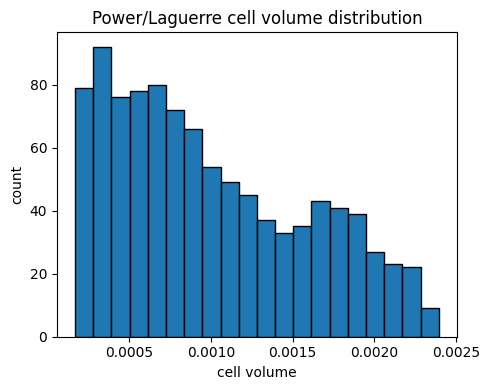

In [16]:
import matplotlib.pyplot as plt

volumes = np.array([c['volume'] for c in result.cells if not c.get('empty', False)])
n_empty = len(result.cells) - len(volumes)

print(f"{len(volumes)} non-empty cells (of {len(result.cells)} sites), "
      f"{n_empty} vanished entirely")
print(f"volume: mean={volumes.mean():.4g}, std={volumes.std():.4g}, "
      f"min={volumes.min():.4g}, max={volumes.max():.4g}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(volumes, bins=20, color='#1f77b4', edgecolor='black')
ax.set_xlabel("cell volume")
ax.set_ylabel("count")
ax.set_title("Power/Laguerre cell volume distribution")
plt.tight_layout()
plt.show()

### Sanity check: sphere volume must not exceed cell volume

For a non-overlapping packing, each site's power/Laguerre cell always contains its own generating sphere entirely, so `sphere_volume / cell_volume` must be `<= 1` for every cell. If the packing is periodic (as here — see `walls=[0,0,0]` in `rcpgen_examples.ipynb`) but tessellated against a non-periodic `pv.Box`, boundary spheres get their cell clipped at the wall instead of wrapped to the opposite face, undercounting the cell volume and pushing this ratio above 1. That's why the cell above uses a periodic `pv.OrthorhombicCell` rather than `pv.Box`.

In [17]:
# Match by id, not list position: cells can vanish (mode='power') and would
# otherwise shift everything after them out of alignment with `centers`/`radii`.
cell_volume_by_id = np.zeros(len(centers))
for c in result.cells:
    cell_volume_by_id[c['id']] = c['volume']

sphere_volume = 4 / 3 * np.pi * radii**3
ratio = sphere_volume / cell_volume_by_id

print(f"sphere/cell volume ratio: max={ratio.max():.4g}, mean={ratio.mean():.4g}")
n_bad = int((ratio > 1.0 + 1e-9).sum())
assert n_bad == 0, f"{n_bad} cells have sphere_volume > cell_volume — check the tessellation domain"
print("OK: every sphere fits inside its own cell.")

sphere/cell volume ratio: max=0.8023, mean=0.5927
OK: every sphere fits inside its own cell.


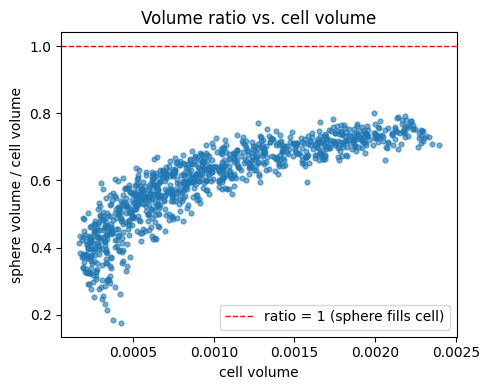

In [18]:
mask = cell_volume_by_id > 0  # exclude vanished (empty) cells

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(cell_volume_by_id[mask], ratio[mask], s=12, alpha=0.6, color='#1f77b4')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='ratio = 1 (sphere fills cell)')
ax.set_xlabel("cell volume")
ax.set_ylabel("sphere volume / cell volume")
ax.set_title("Volume ratio vs. cell volume")
ax.legend()
plt.tight_layout()
plt.show()